# 1. Importación de librerías

In [1]:
import datetime as dt           # Permite trabajar con fechas 
import pandas as pd             # Manipulacion de datos
import matplotlib.pyplot as plt # Construcción de gráficas
import numpy as np

# Librerías para efectuar las regresiones

from sklearn.linear_model import LinearRegression     # Regresor lineal
from sklearn.neural_network import MLPRegressor       # Redes neuronales: perceptrón multicapa
from sklearn.preprocessing import StandardScaler      # Normalización de datos estándar
from sklearn.model_selection import train_test_split  # Separación de datos en entrenamiento y prueba

# 2. Lectura y preparación de datos

En este laboratorio trabajaremos con los datos de generación real del sistema eléctrico colombiano. Los datos fueron tomados empleando la API que ha preparado XM para la consulta de datos en línea. La documentación de la API se encuentra disponible en:

https://github.com/EquipoAnaliticaXM/API_XM

Hemos leído los datos de generación real de todo el sistema desde el 1 de enero de 2015 hasta el 31 de mayo de 2023. Los datos se han guardado en el archivo *data-05.csv*

In [2]:
### Librerias para leer la información provista por XM
### !pip install pydataxm
#from pydataxm import *
#import requests
#import json

#Código para obtener los datos de generación real
#MetricId="Gene"
#objetoAPI = pydataxm.ReadDB()
#df= objetoAPI.request_data(MetricId,Entity,dt.date(2015,1,1),dt.date(2023,5,31))
#df.columns = [x.replace('Values_Hour', '') for x in df_.columns]
#df.drop(columns=['Id', 'Values_code'], inplace=True)
#df.to_csv("data-05.csv")

In [2]:
#Cada fila es una fecha y cada columna es la generación de cada hora
df=pd.read_csv("data-05.csv",parse_dates=['Date'])
df.head(3)

,Unnamed: 0,01,02,03,04,05,06,07,08,09,...,16,17,18,19,20,21,22,23,24,Date
0,0,6069884.02,5827248.17,5574380.78,5395871.77,5258902.97,5119880.44,4669974.39,4683656.10,4900208.29,...,5481657.94,5427387.56,5515891.14,6593392.96,6956259.42,6829378.26,6560070.37,6145473.65,5738183.60,2015-01-01
1,1,5373840.70,5195333.90,5062355.90,5015111.75,5078415.39,5185076.89,5237758.75,5729829.22,6328224.84,...,7169994.48,7022927.68,6989574.48,7974018.78,8217835.86,7972698.86,7536917.61,6940869.91,6378796.02,2015-01-02
2,2,5931434.62,5598248.77,5457974.10,5425350.68,5457169.50,5530965.63,5442553.19,5805345.08,6284184.22,...,6855287.16,6745090.87,6777257.57,7930192.21,8296674.93,8004101.77,7497188.84,6879142.79,6339048.50,2015-01-03


Construimos un *Dataframe* con las columnas que queremos utilizar como posibles explicaciones de la **Demanda**

In [3]:
cols=['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','21','22','23']
DFS=df[cols].stack()
fecha=[]
hora=[]
dato=[]
for ST in DFS.index:
    fecha.append(df['Date'][ST[0]])
    hora.append([ST[1]])
    dato.append(DFS[ST])
hora = [h[0] for h in hora]
data=np.transpose([fecha,hora,dato])

DF=pd.DataFrame(data=data,columns=['Fecha','Hora','Demanda'])
DF['Hora']=pd.to_numeric(DF['Hora'])
DF['DOW']=DF['Fecha'].dt.dayofweek
DF['DOY']=DF['Fecha'].dt.dayofyear
DF['Año']=DF['Fecha'].dt.year
DF['Demanda']=pd.to_numeric(DF['Demanda'])


In [4]:
DF.head(3)

,Fecha,Hora,Demanda,DOW,DOY,Año
0,2015-01-01,1,6069884.02,3,1,2015
1,2015-01-01,2,5827248.17,3,1,2015
2,2015-01-01,3,5574380.78,3,1,2015


# 3. Enriquecimiento de datos

## 3.1. Festivos

Sabemos que la demanda varía los días festivos (feriados). Podemos enriquecer los datos con una variable numérica que vale 0 ó 1 para indicarlo. La información está disponible en el archivo *festivos.csv*. Para construir este archivo se utilizó la librería **holidays_co**, cuya documentación está disponible en:
https://github.com/jmejia32/holidays_co

In [5]:
FEST=pd.read_csv('festivos.csv',parse_dates=['Fecha'])
FEST.head(3)

,Fecha,Festivo
0,2015-01-01,1
1,2015-01-02,0
2,2015-01-03,0


Utilizamos la instrucción **join**, utilizado como **JOIN LEFT**, para cruzar la información de los dos *Dataframe*

In [6]:
DF=DF.join(FEST.set_index('Fecha'),on='Fecha', how='left')
DF.head(5)

,Fecha,Hora,Demanda,DOW,DOY,Año,Festivo
0,2015-01-01,1,6069884.02,3,1,2015,1
1,2015-01-01,2,5827248.17,3,1,2015,1
2,2015-01-01,3,5574380.78,3,1,2015,1
3,2015-01-01,4,5395871.77,3,1,2015,1
4,2015-01-01,5,5258902.97,3,1,2015,1


## 3.2. Cuarentena por Covid19

El periodo de análisis incluye el momento en que se ordenó el confinamiento en cuarentena, como medida para contener la propagación de la epidemia del Covid19. Este hecho incidió en la demanda de energía. Un buen resumen sobre las decisiones tomadas en Colombia se encuentra en:

https://es.wikipedia.org/wiki/Confinamiento_por_la_pandemia_de_COVID-19_en_Colombia

El impacto del confinamiento en la demanda pueda visualizarse en la siguiente figura

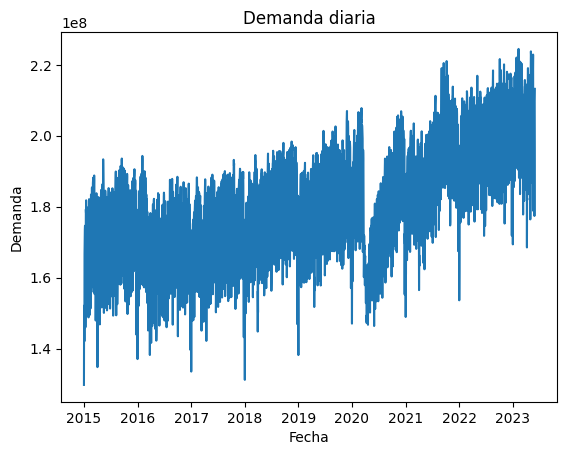

In [7]:
plt.plot(df['Date'],df[cols].sum(axis=1))
plt.title('Demanda diaria')
plt.ylabel('Demanda')
plt.xlabel('Fecha')
plt.show()

Para modelar este fenómeno, utilizaremos una variabke *ad hoc*, que denominaremos **Cuarentena**. Esta variable va a tomar valores contínuos entre $0$ y $1$, intentando representar la intensidad de las medidas de confinamiento. $0$ representa la ausencia de confinamiento, y $1$ el confinamiento máximo. 

Hemos seleccionado tres fechas para construir el modelo, así:

* 25 de marzo de 2020: inicio del confinamiento estricto
* 4 de mayo de 2020: inicio de la suavización del confinamiento
* 31 de agosto de 2020: fin del confinamiento

Además, se ha modelado linealmente la suavización del confinamiento.

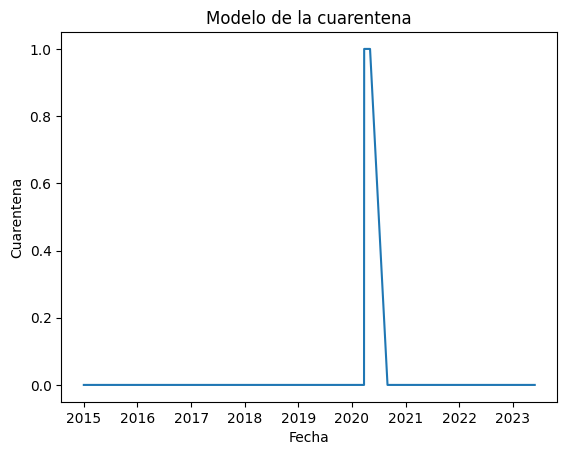

In [8]:
CU=[]
f0=pd.to_datetime('2020-03-25')
f1=pd.to_datetime('2020-05-04')
f2=pd.to_datetime('2020-08-31')
for fecha in DF['Fecha']:
    if fecha < f0:
        CU.append(0)
    else:
        if fecha < f1:
            CU.append(1)
        else:
            if fecha < f2:
                x=(fecha-f1).days/(f2-f1).days
                CU.append(1-x)
            else:
                CU.append(0)
DF['Cuarentena']=CU
plt.plot(DF['Fecha'],DF['Cuarentena'])
plt.title('Modelo de la cuarentena')
plt.ylabel('Cuarentena')
plt.xlabel('Fecha')
plt.show()

In [9]:
DF.head(3)

,Fecha,Hora,Demanda,DOW,DOY,Año,Festivo,Cuarentena
0,2015-01-01,1,6069884.02,3,1,2015,1,0.0
1,2015-01-01,2,5827248.17,3,1,2015,1,0.0
2,2015-01-01,3,5574380.78,3,1,2015,1,0.0


# 4. Descubrimiento de explicaciones
## 4.1. El regresor lineal

In [10]:
X=np.array(DF[['Año','DOY','DOW','Hora']])
y=np.array(DF[['Demanda']])
#X.shape
reg = LinearRegression().fit(X, y)
print("Score usando las variables Año, DOY, DOW y Hora")
print(reg.score(X, y))

X=np.array(DF[['Año','DOY','DOW','Hora','Festivo']])
y=np.array(DF[['Demanda']])
#X.shape
reg = LinearRegression().fit(X, y)
print("\nScore usando las variables Año, DOY, DOW, Hora y Festivo")
print(reg.score(X, y))

X=np.array(DF[['Año','DOY','DOW','Hora','Festivo','Cuarentena']])
y=np.array(DF[['Demanda']])
#X.shape
reg = LinearRegression().fit(X, y)
print("\nScore usando las variables Año, DOY, DOW, Hora, Festivo y Cuarentena")
print(reg.score(X, y))


Score usando las variables Año, DOY, DOW y Hora
0.6002983007605825

Score usando las variables Año, DOY, DOW, Hora y Festivo
0.6444151286553794

Score usando las variables Año, DOY, DOW, Hora, Festivo y Cuarentena
0.6695247746324879


Una forma de visualizar el desempeño del regresor es comparar su predicción con los datos reales. El mejor desempeño posible se debe ver como una línea recta (la recta identidad). Para facilitar la valoración del desempeño, trazamos esa recta.

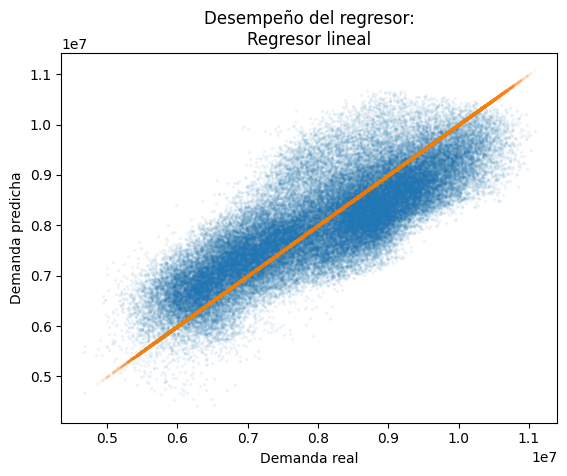

In [11]:
pred=reg.predict(X)
plt.scatter(y,pred,s=2,alpha=0.05)
plt.scatter(y,y,s=2,alpha=0.05)
plt.xlabel('Demanda real')
plt.ylabel('Demanda predicha')
plt.title('Desempeño del regresor:\nRegresor lineal')
plt.show()

## 4.2. Regresor lineal sobre datos normalización. Interpretabilidad.

Es posible obtener los parámetros del modelo lineal:

$y = a_0 + a_1x_1 + a_2x_2 + \cdots + a_nx_n$

$a_0$ es el cruce por cero (**intercept_**), y los demas valores $a_i$ son los coeficientes (**coef_**)

In [12]:
print(reg.coef_)
print(reg.intercept_)

[[ 1.86697230e+05  9.30997265e+02 -1.41517655e+05  1.20620333e+05
  -1.19271393e+06 -1.22973575e+06]]
[-3.69941265e+08]


El peso de cada variable explicativa está dado por su coeficiente. Sin embargo es muy difícil analizar cuál es la importancia relativa de cada variable, porque los coeficientes están afectados por las unidades de las variables.

Para ganar interpretabilidad, podemos normalizar las variables y volver a obtener el regresor y sus parámetros:


In [13]:
scaler = StandardScaler()
scaler.fit(X)
XN=scaler.transform(X)
scaler.fit(y)
yN=scaler.transform(y)

Score usando las variables normalizadas Año, DOY, DOW, Hora, Festivo y Cuarentena
0.6695247746324854

Término independiente:
[2.75348749e-15]

Coeficientes:
[[ 0.37352003  0.08089782 -0.2323854   0.65692392 -0.21100949 -0.15973541]]


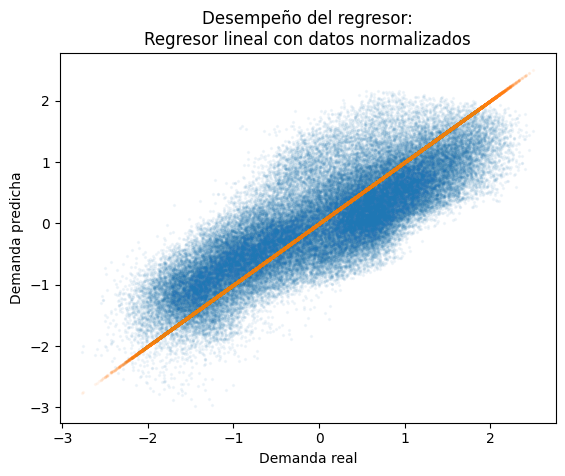

In [14]:
reg = LinearRegression().fit(XN, yN)
print("Score usando las variables normalizadas Año, DOY, DOW, Hora, Festivo y Cuarentena")
print(reg.score(XN, yN))
print("\nTérmino independiente:")
print(reg.intercept_)
print("\nCoeficientes:")
print(reg.coef_)

pred=reg.predict(XN)
plt.scatter(yN,pred,s=2,alpha=0.05)
plt.scatter(yN,yN,s=2,alpha=0.05)
plt.xlabel('Demanda real')
plt.ylabel('Demanda predicha')
plt.title('Desempeño del regresor:\nRegresor lineal con datos normalizados')
plt.show()

# 4.3. Redes neuronales.

El modelo lineal es de fácil interpretación, pero es muy limitado para modelar comportamientos complejos. De hecho, sabemos que el efecto de la variable **Hora** sobre la demanda está lejos de parecerse a una línea recta (el perfil de demanda suele denominarse la *curva de pato*).

Utilizaremos ahora una red neuronal como regresor. En concreto, utilzaremos un **Perceptrón multicapa** como regresor, con las siguientes definiciones:
* Número de capas ocultas: 1
* Número de nodos en la capa oculta: 20
* Función de activación: $f(x) = max(0, x)$

La documentación puede consultarse en:
https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html

**Nota:** a ejecución de este código puede tardar algunos minutos.

Score usando una Red Neuronal:
0.944141863416794


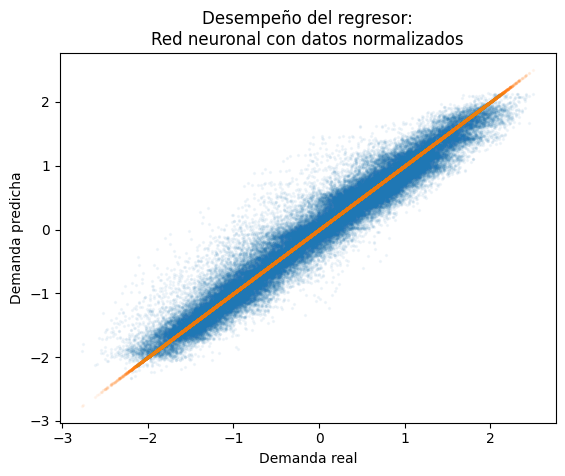

In [15]:
XNN=XN
yNN=np.ravel(yN) ## formato 1D
reg = MLPRegressor(max_iter=500,hidden_layer_sizes=(20,)).fit(XNN, yNN)
print("Score usando una Red Neuronal:")
print(reg.score(XNN, yNN))
pred=reg.predict(XNN)

plt.scatter(yNN,pred,s=2,alpha=0.05)
plt.scatter(yNN,yNN,s=2,alpha=0.05)
plt.xlabel('Demanda real')
plt.ylabel('Demanda predicha')
plt.title('Desempeño del regresor:\nRed neuronal con datos normalizados')
plt.show()

## 4.3.1. Efecto del número de iteraciones máximas

Para visualizar el progreso del algoritmo de entrenamiento conforme avanzan las iteraciones, podemos comparar el *score* limitando el **número máximo de iteraciones**. El algoritmo informa si no ha logrado el punto de convergencia con esas iteraciones:

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


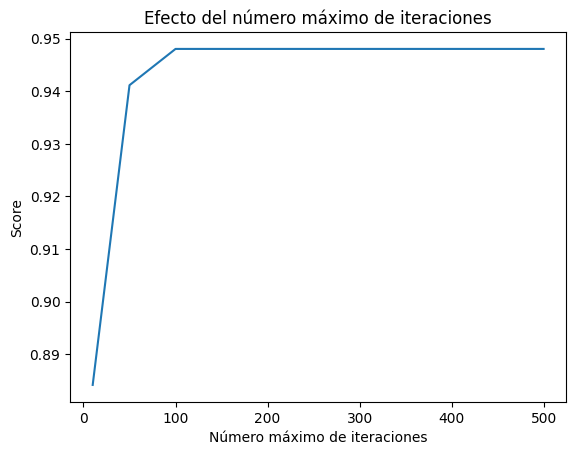

In [18]:
itermax=[10,50,100,250,500]
scores=[]
for im in itermax:
    reg = MLPRegressor(max_iter=im,hidden_layer_sizes=(20,),random_state=1).fit(XNN, yNN)
    scores.append(reg.score(XNN, yNN))
plt.title('Efecto del número máximo de iteraciones')
plt.plot(itermax,scores)
plt.xlabel('Número máximo de iteraciones')
plt.ylabel('Score')
plt.show()


## 4.3.2. Redes neuronales sobre datos sin normalizar.

Para efectos de comparación, incluimos aquí el código para obtener el regresor a partir de los datos sin normalizar. El **Desempeño del algoritmo** se ve notablemente afectado por la escala de las variables de entrada y salida. El deterioro en el deseméño se observa en:

* La capacidad de predicción (*score*)
* El tiempo de ejecución del algoritmo

Para efectuar una prueba, descomente las lpineas del siguiente código y ejecute el bloque.
**Nota:** La ejecución puede ser extremadamente demorada

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


0.43538703822631264


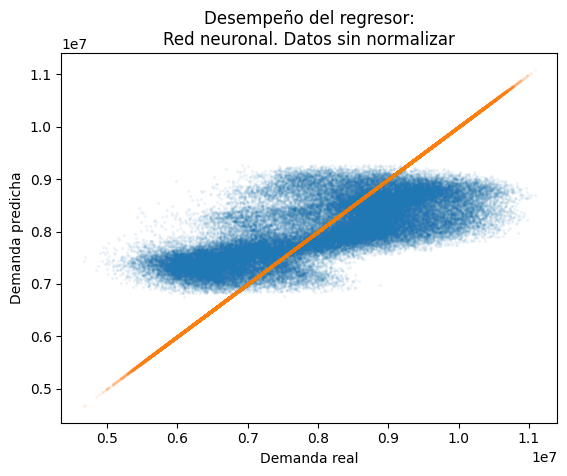

In [19]:
XNNo=X
yNNo=np.ravel(y)
reg = MLPRegressor(max_iter=500,hidden_layer_sizes=(20,)).fit(XNNo, yNNo)
print(reg.score(XNNo, yNNo))
pred=reg.predict(XNNo)
plt.scatter(yNNo,pred,s=2,alpha=0.05)
plt.scatter(yNNo,yNNo,s=2,alpha=0.05)
plt.xlabel('Demanda real')
plt.ylabel('Demanda predicha')
plt.title('Desempeño del regresor:\nRed neuronal. Datos sin normalizar')
plt.show()

## 4.4. Separación entre datos de entrenamiento y prueba

Es muy importante determinar la capacidad de generalización del predictor. La estrategia usual consiste en reservar un subconjunto de los datos disponibles como **datos de prueba**. El predictor se construye empleando solamente los demás datos (**datos de entrenamiento**).

La función **train_test_split** permite obtener los subconjuntos de entrenamiento y prueba, tanto para las variables de entrada como las de salida, especificando el tamaño del conjunto de entrenamiento.

El tamaño se define con el parámetro **train_size**, que toma valoires entre $0$ y $1$, y representa la fracción del conjunto de datos originales que debe tomarse. 

El valor por defecto de **train_size** es $0.75$. En este laboratorio empleamos valores inusualmente bajos para mostrar la importancia de verificar la capacidad de generalización. El experimento lo hacemos con el regresor lineal, pero puede probarse el efecto tabién sobre la red neuronal.

Debido a que la construcción de los conjuntos de entrenamiento y prueba es aleatoria, conviene correr en varias ocasiones el siguiente código para visualizar esa aleatoriedad:

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


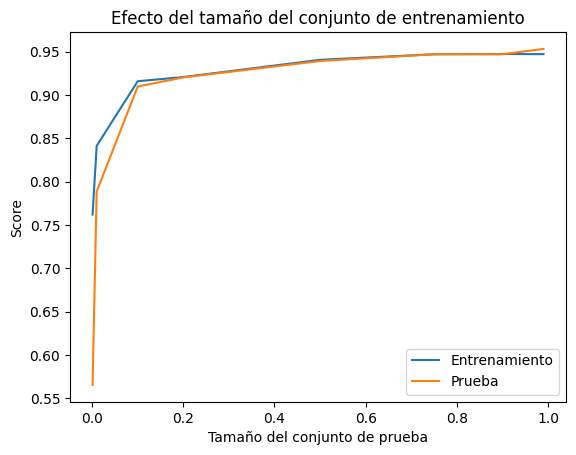

In [24]:
separación=[0.001,0.01,0.1,0.2,0.5,0.75,0.9,0.99]
scores_train=[]
scores_test=[]
for sep in separación:
    XNN_train, XNN_test, yNN_train, yNN_test = train_test_split(XNN, yNN,train_size=sep)
    reg = MLPRegressor(max_iter=200,hidden_layer_sizes=(20,),random_state=1).fit(XNN_train, yNN_train)
    #reg = LinearRegression().fit(XNN_train, yNN_train)
    scores_train.append(reg.score(XNN_train, yNN_train))
    scores_test.append(reg.score(XNN_test, yNN_test))

plt.title('Efecto del tamaño del conjunto de entrenamiento')
plt.plot(separación,scores_train,label='Entrenamiento')
plt.plot(separación,scores_test,label='Prueba')
plt.legend()
plt.xlabel('Tamaño del conjunto de prueba')
plt.ylabel('Score')
plt.show()


# 5. Ejercicio sugerido

* Repita el ejercicio de regresión ignorando la información de los días festivos y la cuarentena, y compare los resultados.
* Incremente el número de neuronas en la capa oculta y vuelva a entrenarla. Compare los resultados y el desmpeño.

Primero sin cuarentena

In [25]:
X=np.array(DF[['Año','DOY','DOW','Hora','Festivo']])
y=np.array(DF[['Demanda']])

In [26]:
scaler = StandardScaler()
scaler.fit(X)
XN=scaler.transform(X)
scaler.fit(y)
yN=scaler.transform(y)

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


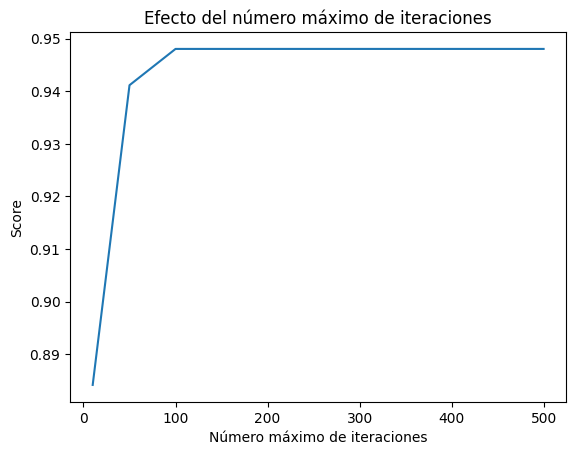

In [27]:
itermax=[10,50,100,250,500]
scores=[]
for im in itermax:
    reg = MLPRegressor(max_iter=im,hidden_layer_sizes=(20,),random_state=1).fit(XNN, yNN)
    scores.append(reg.score(XNN, yNN))
plt.title('Efecto del número máximo de iteraciones')
plt.plot(itermax,scores)
plt.xlabel('Número máximo de iteraciones')
plt.ylabel('Score')
plt.show()


c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Score usando una Red Neuronal:
0.9311197172307368


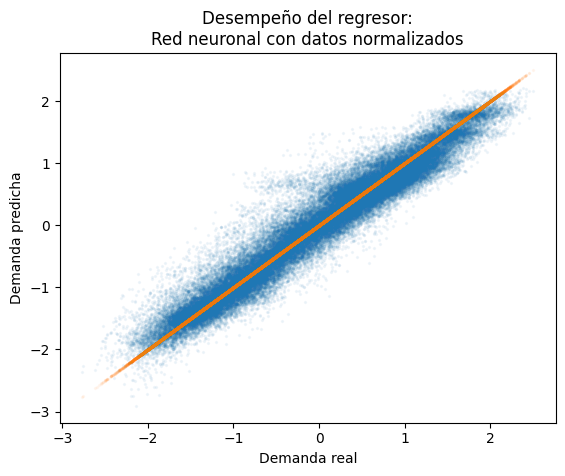

In [28]:
XNN=XN
yNN=np.ravel(yN) ## formato 1D
reg = MLPRegressor(max_iter=100,hidden_layer_sizes=(20,)).fit(XNN, yNN)
print("Score usando una Red Neuronal:")
print(reg.score(XNN, yNN))
pred=reg.predict(XNN)

plt.scatter(yNN,pred,s=2,alpha=0.05)
plt.scatter(yNN,yNN,s=2,alpha=0.05)
plt.xlabel('Demanda real')
plt.ylabel('Demanda predicha')
plt.title('Desempeño del regresor:\nRed neuronal con datos normalizados')
plt.show()

El desempeño de la red neuronal, excluyendo la variable cuarentena, fue ligeramente menor con un 0.93.

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


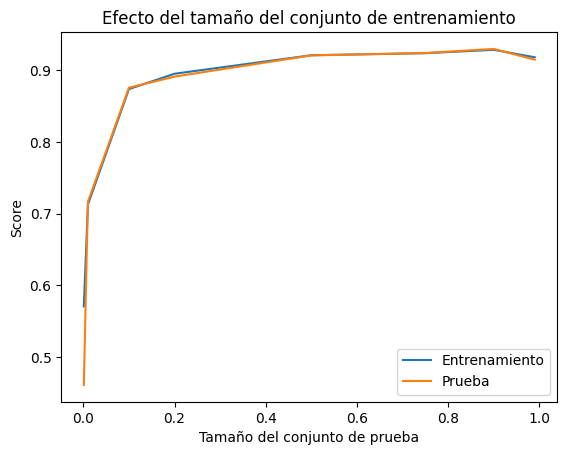

In [29]:
separación=[0.001,0.01,0.1,0.2,0.5,0.75,0.9,0.99]
scores_train=[]
scores_test=[]
for sep in separación:
    XNN_train, XNN_test, yNN_train, yNN_test = train_test_split(XNN, yNN,train_size=sep)
    reg = MLPRegressor(max_iter=100,hidden_layer_sizes=(20,),random_state=1).fit(XNN_train, yNN_train)
    #reg = LinearRegression().fit(XNN_train, yNN_train)
    scores_train.append(reg.score(XNN_train, yNN_train))
    scores_test.append(reg.score(XNN_test, yNN_test))

plt.title('Efecto del tamaño del conjunto de entrenamiento')
plt.plot(separación,scores_train,label='Entrenamiento')
plt.plot(separación,scores_test,label='Prueba')
plt.legend()
plt.xlabel('Tamaño del conjunto de prueba')
plt.ylabel('Score')
plt.show()


Los scores utilizando la división de entrenamiento y prueba fueron acertadas con esta ejecución, dando que a partir de un 40% un score por encima del 0.9, dando su pico en el 90%.

Ahora sin festivos

In [30]:
X=np.array(DF[['Año','DOY','DOW','Hora']])
y=np.array(DF[['Demanda']])
scaler = StandardScaler()
scaler.fit(X)
XN=scaler.transform(X)
scaler.fit(y)
yN=scaler.transform(y)

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


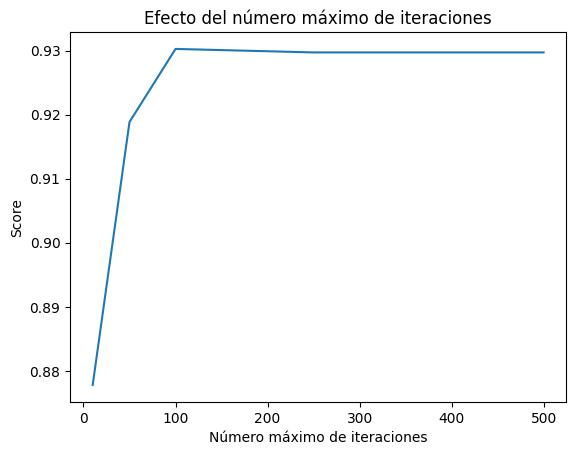

In [31]:
itermax=[10,50,100,250,500]
scores=[]
for im in itermax:
    reg = MLPRegressor(max_iter=im,hidden_layer_sizes=(20,),random_state=1).fit(XNN, yNN)
    scores.append(reg.score(XNN, yNN))
plt.title('Efecto del número máximo de iteraciones')
plt.plot(itermax,scores)
plt.xlabel('Número máximo de iteraciones')
plt.ylabel('Score')
plt.show()


100 es el número óptimo de iteraciones

Score usando una Red Neuronal:
0.8932490736967219


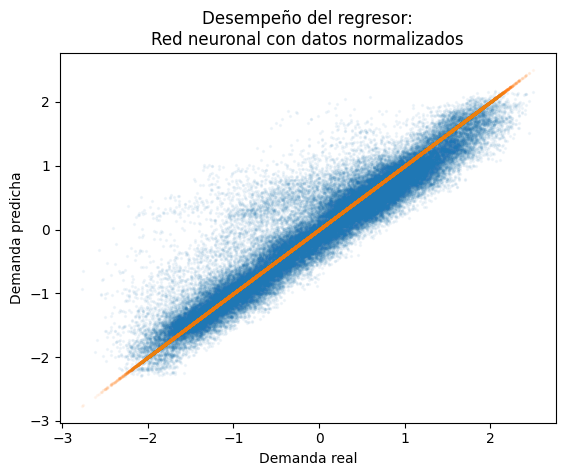

In [32]:
XNN=XN
yNN=np.ravel(yN) ## formato 1D
reg = MLPRegressor(max_iter=100,hidden_layer_sizes=(20,)).fit(XNN, yNN)
print("Score usando una Red Neuronal:")
print(reg.score(XNN, yNN))
pred=reg.predict(XNN)

plt.scatter(yNN,pred,s=2,alpha=0.05)
plt.scatter(yNN,yNN,s=2,alpha=0.05)
plt.xlabel('Demanda real')
plt.ylabel('Demanda predicha')
plt.title('Desempeño del regresor:\nRed neuronal con datos normalizados')
plt.show()

El desempeño disminuyó considerablemente si se compara con el escenario donde se utilizaron todas las variables. El gráfico muestra una mayor dispersión entre la Demanda Real y la Demanda predicha.

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


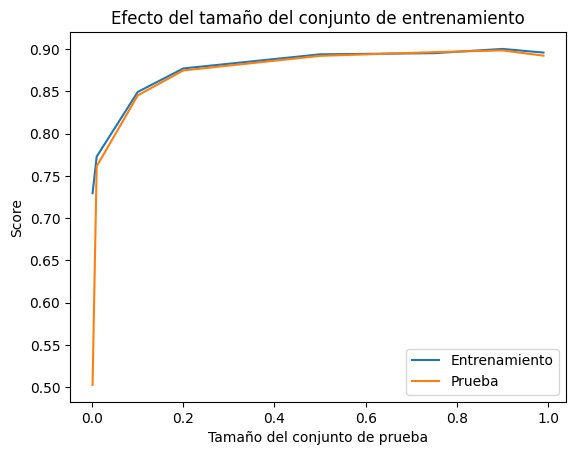

: 

In [ ]:
separación=[0.001,0.01,0.1,0.2,0.5,0.75,0.9,0.99]
scores_train=[]
scores_test=[]
for sep in separación:
    XNN_train, XNN_test, yNN_train, yNN_test = train_test_split(XNN, yNN,train_size=sep)
    reg = MLPRegressor(max_iter=200,hidden_layer_sizes=(20,),random_state=1).fit(XNN_train, yNN_train)
    #reg = LinearRegression().fit(XNN_train, yNN_train)
    scores_train.append(reg.score(XNN_train, yNN_train))
    scores_test.append(reg.score(XNN_test, yNN_test))

plt.title('Efecto del tamaño del conjunto de entrenamiento')
plt.plot(separación,scores_train,label='Entrenamiento')
plt.plot(separación,scores_test,label='Prueba')
plt.legend()
plt.xlabel('Tamaño del conjunto de prueba')
plt.ylabel('Score')
plt.show()


Los scores utilizando la división de entrenamiento y prueba fueron acertadas con esta ejecución, dando que a partir de un 40% un score por encima del 0.9, dando su pico en el 90%.